In [1]:
import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.path import Path

# Ajout du chemin vers le dossier git
sys.path.insert(0, os.path.abspath('imodal_git'))

# Imports de la librairie
import imodal
from imodal import Utilities

# Configuration
Utilities.set_compute_backend('torch')
torch.manual_seed(1337)

torch.set_default_dtype(torch.float64)
imodal.Utilities.set_compute_backend('torch') 

%load_ext autoreload
%autoreload 2
import func as f

import importlib
importlib.reload(f)

<module 'func' from '/teamspace/studios/this_studio/2025-Projet-radiologie-interventionnelle/func.py'>

# Création des données "jouet"

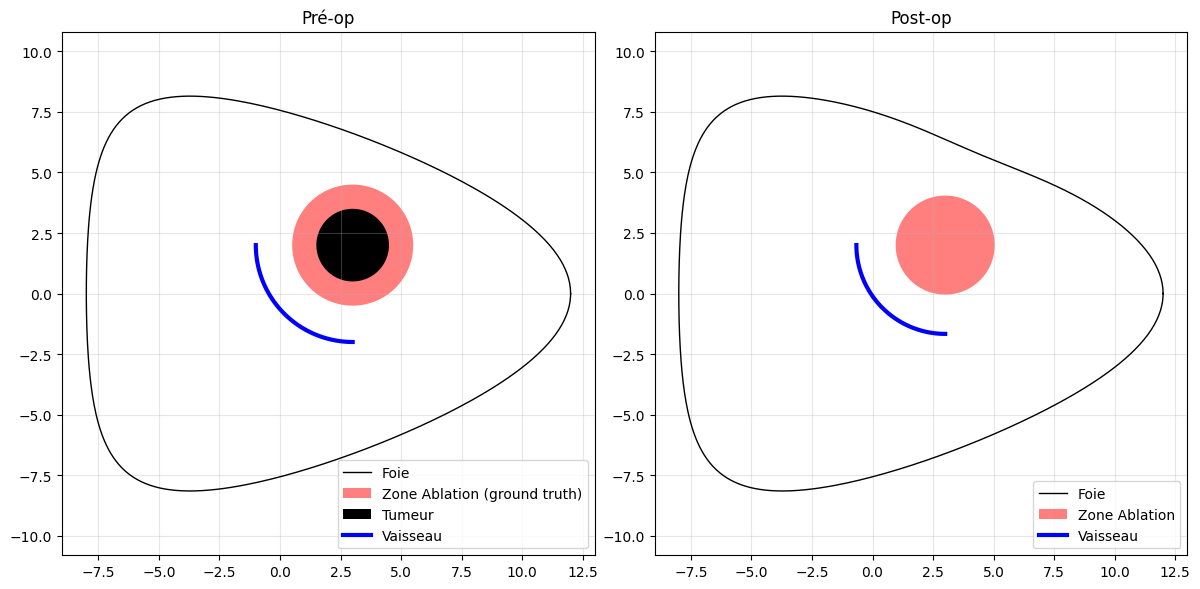

In [2]:
# DEFINITION DES PARAMETRES DES OBJETS JOUET
# Tumeur
centre_tumeur = np.array([3.0, 2.0])
rayon_tumeur = 1.5

# Zone d'ablation
marge = 1.0  # 1 cm
rayon_ablation = rayon_tumeur + marge

# Paramètres de la rétractation (ground truth)
FORCE_RETRACTATION = 0.3 # Assez fort pour être visible
RAYON_INFLUENCE = rayon_ablation # Assez large pour toucher les vaisseaux

# CREATION DES OBJETS JOUET (PRE-OP)
# Foie
foie_pre = f.get_liver_shape()

# Tumeur
tumeur_pre = f.get_circle(centre_tumeur, rayon_tumeur)

# Zone d'Ablation (ground truth)
zone_ablation_pre = f.get_circle(centre_tumeur, rayon_ablation)

# Repère
start_angle = 180
end_angle = 270
rayon_vaisseau = rayon_ablation + 1.5  # Positionné à l'extérieur de la zone d'ablation
arc_pre= f.get_arc_vessel(centre_tumeur, radius_vessel=rayon_vaisseau, start_angle=start_angle,  end_angle=end_angle)
vaisseaux_pre= [arc_pre]

# SIMULATION DE L'INTERVENTION (POST-OP)
# On applique ta fonction apply_retraction à TOUT le monde
foie_post = f.apply_retraction(foie_pre, centre_tumeur, strength=FORCE_RETRACTATION, radius_influence=RAYON_INFLUENCE)

# Note: La tumeur n'existe plus physiquement, mais on calcule la déformation de l'espace
# La zone d'ablation visible est la version rétractée de la zone théorique
zone_ablation_post = f.apply_retraction(zone_ablation_pre, centre_tumeur, strength=FORCE_RETRACTATION, radius_influence=RAYON_INFLUENCE)

# --- SIMULATION POST-OP ---
vaisseaux_post = []
for segment in vaisseaux_pre:
    seg_post = f.apply_retraction(segment, centre_tumeur, strength=FORCE_RETRACTATION, radius_influence=RAYON_INFLUENCE)
    vaisseaux_post.append(seg_post)

f.visualiser_intervention(
    foie_pre, 
    zone_ablation_pre, 
    tumeur_pre, 
    vaisseaux_pre,  # Votre liste spécifique de vaisseaux
    foie_post, 
    zone_ablation_post, 
    vaisseaux_post
)

# Calcul de la dilatation "réelle"

In [3]:
# Fonction pour calculer l'aire d'un polygone (Formule des lacets)
def calculer_aire(points):
    x = points[:, 0]
    y = points[:, 1]
    return 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

# 1. Calcul des aires réelles basées sur tes objets jouets
aire_pre_op = calculer_aire(zone_ablation_pre)   # La cible (La vérité)
aire_post_op = calculer_aire(zone_ablation_post) # Le point de départ (Ce qui reste)

# B. De combien faut-il gonfler pour revenir à la normale ? (Objectif du modèle)
# C'est CE chiffre que ton modèle imodal doit essayer d'atteindre.
dilatation_requise = (aire_pre_op - aire_post_op) / aire_post_op * 100

print(f"Aire post-opératoire (point de départ) : {aire_post_op:.2f} cm²")
print(f"Aire pré-opératoire (cible) : {aire_pre_op:.2f} cm²")
print(f"DILATATION À TROUVER (CALCULEE EN SURFACE) : +{dilatation_requise:.2f} %")

Aire post-opératoire (point de départ) : 13.13 cm²
Aire pré-opératoire (cible) : 19.62 cm²
DILATATION À TROUVER (CALCULEE EN SURFACE) : +49.43 %


# Registration ''en 1 fois''

registration_imodal (LBFGS):  60%|██████    | 15/25 [00:03<00:02,  4.07it/s, calls=15, loss=6.2447e-02]


 DILATATION OBTENUE APRÈS OPTIMISATION :
Aire initiale (Avant déformation)   : 13.13
Aire finale (Après déformation)     : 16.84
Aire cible (Zone d'ablation pré-op) : 19.62
--> DILATATION SIMULÉE OBTENUE    : +28.27 %


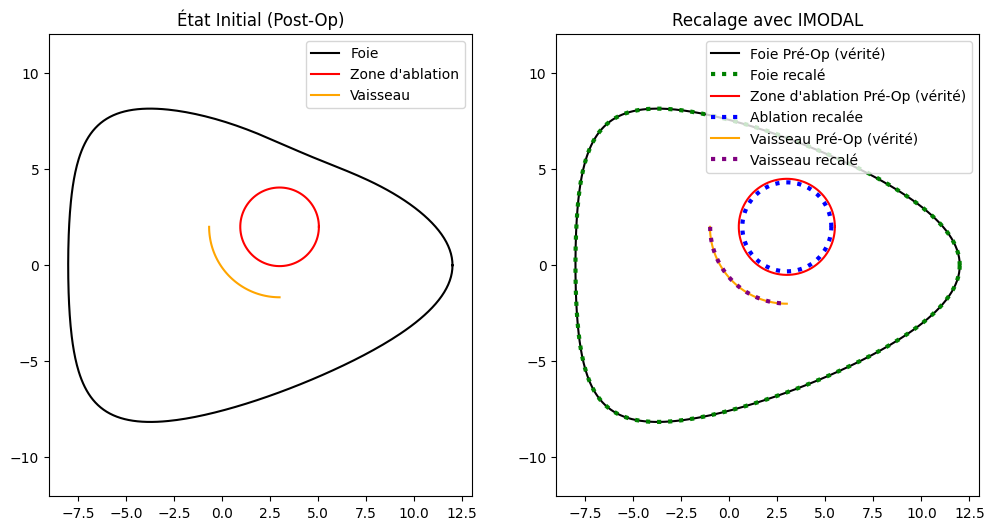

In [11]:
mes_parametres = {
    'sigma_local': 0.5,
    'nu_local': 0.01,
    'sigma_global': 2.0,
    'nu_global': 1.0,
    'lamb': 0.1,
    'device': 'cpu'
}

foie_res, vais_res, abla_res, force_loc, force_glob, historique_loss = f.registration_imodal(
    foie_pre, 
    foie_post, 
    vaisseaux_pre, 
    vaisseaux_post, 
    zone_ablation_post, 
    params=mes_parametres,
    dtype=torch.float64
)

# ==========================================================
# CALCUL DES AIRES
# ==========================================================
aire_initiale = calculer_aire(zone_ablation_post)
poly_final = abla_res
aire_simulee = calculer_aire(poly_final)
aire_vérité = calculer_aire(zone_ablation_pre)
dilatation_obtenue = (aire_simulee - aire_initiale) / aire_initiale * 100

print("="*50)
print(" DILATATION OBTENUE APRÈS OPTIMISATION :")
print(f"Aire initiale (Avant déformation)   : {aire_initiale:.2f}")
print(f"Aire finale (Après déformation)     : {aire_simulee:.2f}")
print(f"Aire cible (Zone d'ablation pré-op) : {aire_vérité:.2f}")
print(f"--> DILATATION SIMULÉE OBTENUE    : +{dilatation_obtenue:.2f} %")
print("="*50)

# ==========================================================
# AFFICHAGE
# ==========================================================
plt.figure(figsize=(12, 6))

# --- GRAPHE GAUCHE (AVANT) ---
plt.subplot(1, 2, 1)
plt.title("État Initial (Post-Op)")
plt.plot(foie_post[:, 0], foie_post[:, 1], 'k-', label='Foie')
# On montre l'ablation initiale
plt.plot(zone_ablation_post[:, 0], zone_ablation_post[:, 1], 'r-', label="Zone d'ablation")
# On montre les vaisseaux initiaux
for i, seg in enumerate(vaisseaux_post):
    label = 'Vaisseau' if i == 0 else ""
    plt.plot(seg[:, 0], seg[:, 1], color='orange', linestyle='-', label=label)
plt.legend()
plt.axis('equal')

# --- GRAPHE DROITE (APRÈS) ---
plt.subplot(1, 2, 2)
plt.title("Recalage avec IMODAL")

# 1. La Cible (Ce qu'on voulait atteindre)
plt.plot(foie_pre[:, 0], foie_pre[:, 1], 'k-', label='Foie Pré-Op (vérité)')

# 2. Le Foie Recalé (Résultat global)
plt.plot(foie_res[:, 0], foie_res[:, 1], 'g:', lw=3, label='Foie recalé') 

# 3. L'Ablation Initiale (Fantôme pour comparaison)
plt.plot(zone_ablation_pre[:, 0], zone_ablation_pre[:, 1], 'r-', label="Zone d'ablation Pré-Op (vérité)")

# 4. L'ABLATION DILATÉE (Résultat du modèle)
plt.plot(abla_res[:, 0], abla_res[:, 1], 'b:', lw=3, label='Ablation recalée') 

# 5. Les vaisseaux initiaux (Fantômes pour comparaison)
for i, seg in enumerate(vaisseaux_pre):
    label = 'Vaisseau Pré-Op (vérité)' if i == 0 else ""
    plt.plot(seg[:, 0], seg[:, 1], color='orange', linestyle='-', label=label)

# 6. Les vaisseaux recalés
for i, seg in enumerate(vais_res):
    label = 'Vaisseau recalé' if i == 0 else ""
    plt.plot(seg[:, 0], seg[:, 1], color='purple', linestyle=':', lw=3, label=label) 

plt.legend()
plt.axis('equal')
plt.show()